# Loan Default Risk Analytics — Digital Lending Platform (NBFC)

**Business Problem:** The credit risk team wants to understand *which applicant segments default most often* and needs a data-driven early-warning score to flag high-risk loan applications before disbursement.

**Role simulated:** Data Analyst working with the Risk & Credit team.

**Tools used:** SQL (SQLite), Python (Pandas, NumPy), Matplotlib/Seaborn for EDA, Scikit-learn for a baseline risk model.

**Dataset:** 6,000 synthetic loan applications (Jan 2024 – Dec 2025) generated to reflect realistic NBFC lending patterns — includes intentional data quality issues (duplicates, missing income, invalid ages) to demonstrate a real cleaning workflow.


## 1. Load Data into SQL (simulating a company database)

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

raw = pd.read_csv("loan_applications_raw.csv", parse_dates=["application_date"])
conn = sqlite3.connect(":memory:")
raw.to_sql("loan_applications", conn, index=False, if_exists="replace")

print(f"Rows loaded into SQL table: {len(raw)}")
raw.head()


Rows loaded into SQL table: 6040


,applicant_id,age,gender,state,employment_type,monthly_income,credit_score,loan_purpose,loan_amount,tenure_months,interest_rate,emi,existing_loans,num_dependents,application_date,debt_to_income,default_flag
0,APP101901,39,Male,West Bengal,Salaried,55800.0,699,Education,47000.0,60,11.23,1027.0,0,2,2024-09-16,0.02,0
1,APP105089,43,Male,Tamil Nadu,Salaried,21200.0,731,Personal,376000.0,36,13.68,12792.0,2,3,2024-12-23,1.81,0
2,APP105813,24,Female,Maharashtra,Salaried,52600.0,679,Personal,319000.0,84,13.25,5847.0,0,1,2025-05-23,0.11,1
3,APP102381,39,Male,Telangana,Salaried,43300.0,574,Home Renovation,158000.0,24,14.63,7633.0,0,4,2024-04-18,0.18,0
4,APP101625,53,Female,Maharashtra,Self-Employed,36800.0,681,Medical,288000.0,12,13.30,25764.0,0,3,2025-11-08,0.70,0


## 2. SQL — Answering Business Questions

A Data Analyst's first job is to query the existing production database directly — no need to create data, it already lives in the company's system.

In [2]:
query = '''
SELECT state,
       COUNT(*) AS total_applications,
       ROUND(AVG(default_flag)*100, 2) AS default_rate_pct
FROM loan_applications
GROUP BY state
ORDER BY default_rate_pct DESC;
'''
pd.read_sql(query, conn)


,state,total_applications,default_rate_pct
0,Tamil Nadu,626,35.30
1,Rajasthan,424,34.91
2,Delhi,645,34.57
3,West Bengal,476,33.82
4,Uttar Pradesh,762,33.73
5,Punjab,374,33.69
6,Gujarat,532,32.33
7,Maharashtra,958,31.73
8,Karnataka,738,30.76
9,Telangana,505,29.11


In [3]:
query = '''
SELECT employment_type,
       COUNT(*) AS applications,
       ROUND(AVG(monthly_income), 0) AS avg_income,
       ROUND(AVG(default_flag)*100, 2) AS default_rate_pct
FROM loan_applications
GROUP BY employment_type
ORDER BY default_rate_pct DESC;
'''
pd.read_sql(query, conn)


,employment_type,applications,avg_income,default_rate_pct
0,Self-Employed,1876,38544.0,38.75
1,Salaried,3210,45131.0,30.56
2,Business Owner,954,61126.0,29.14


In [4]:
query = '''
SELECT
    CASE
        WHEN credit_score < 600 THEN '<600 (Poor)'
        WHEN credit_score BETWEEN 600 AND 699 THEN '600-699 (Fair)'
        WHEN credit_score BETWEEN 700 AND 799 THEN '700-799 (Good)'
        ELSE '800+ (Excellent)'
    END AS credit_band,
    COUNT(*) AS applications,
    ROUND(AVG(default_flag)*100, 2) AS default_rate_pct
FROM loan_applications
GROUP BY credit_band
ORDER BY default_rate_pct DESC;
'''
pd.read_sql(query, conn)


,credit_band,applications,default_rate_pct
0,<600 (Poor),1137,48.28
1,600-699 (Fair),2390,36.15
2,700-799 (Good),1942,24.67
3,800+ (Excellent),571,16.46


**Insight:** Credit score is a strong early signal — applicants with 'Poor' scores default ~3x more often than 'Excellent' scores.

## 3. Data Cleaning

The raw export has realistic issues: duplicate applicant records, invalid negative ages (entry errors), and missing income values.

In [5]:
df = raw.copy()
before = len(df)

# Remove duplicate applicant records
df = df.drop_duplicates(subset="applicant_id")
print(f"Duplicates removed: {before - len(df)}")

# Fix invalid negative ages
neg_count = (df["age"] < 0).sum()
df["age"] = df["age"].abs()
print(f"Negative ages corrected: {neg_count}")

# Impute missing income with the median for that employment type (more accurate than overall median)
missing = df["monthly_income"].isna().sum()
df["monthly_income"] = df.groupby("employment_type")["monthly_income"].transform(lambda x: x.fillna(x.median()))
print(f"Missing income values imputed: {missing}")

# Sanity filters
df = df[(df["age"] >= 18) & (df["age"] <= 70)]
df = df[df["monthly_income"] > 0]

print(f"Final clean shape: {df.shape}")


Duplicates removed: 40
Negative ages corrected: 15
Missing income values imputed: 180
Final clean shape: (6000, 17)


## 4. Feature Engineering

In [6]:
df["emi_to_income_ratio"] = (df["emi"] / df["monthly_income"]).round(2)
df["credit_band"] = pd.cut(df["credit_score"], bins=[0,599,699,799,900],
                            labels=["Poor","Fair","Good","Excellent"])
df["age_group"] = pd.cut(df["age"], bins=[18,30,40,50,70],
                          labels=["21-30","31-40","41-50","51-60"])
df["loan_to_income_ratio"] = (df["loan_amount"] / (df["monthly_income"]*12)).round(2)
df["is_self_employed"] = (df["employment_type"] != "Salaried").astype(int)

df.to_csv("loan_applications_clean.csv", index=False)
df[["emi_to_income_ratio","credit_band","age_group","loan_to_income_ratio"]].head()


,emi_to_income_ratio,credit_band,age_group,loan_to_income_ratio
0,0.02,Fair,31-40,0.07
1,0.60,Good,41-50,1.48
2,0.11,Fair,21-30,0.51
3,0.18,Poor,31-40,0.30
4,0.70,Fair,51-60,0.65


## 5. Exploratory Data Analysis

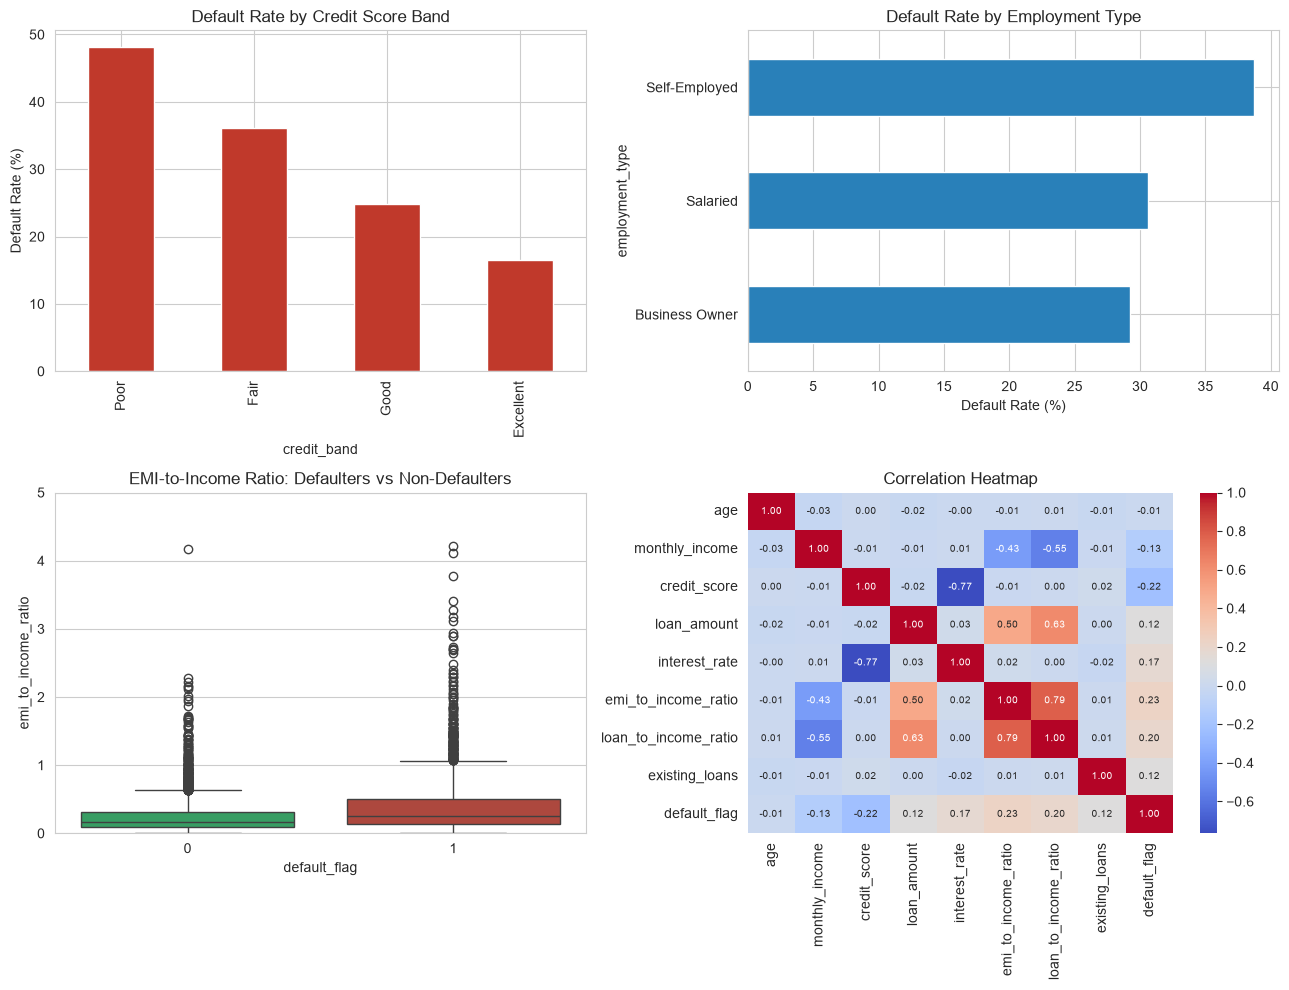

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

band_default = df.groupby("credit_band", observed=True)["default_flag"].mean() * 100
band_default.plot(kind="bar", ax=axes[0,0], color="#c0392b")
axes[0,0].set_title("Default Rate by Credit Score Band")
axes[0,0].set_ylabel("Default Rate (%)")

emp_default = df.groupby("employment_type")["default_flag"].mean() * 100
emp_default.sort_values().plot(kind="barh", ax=axes[0,1], color="#2980b9")
axes[0,1].set_title("Default Rate by Employment Type")
axes[0,1].set_xlabel("Default Rate (%)")

sns.boxplot(data=df, x="default_flag", y="emi_to_income_ratio", hue="default_flag",
            ax=axes[1,0], palette=["#27ae60","#c0392b"], legend=False)
axes[1,0].set_title("EMI-to-Income Ratio: Defaulters vs Non-Defaulters")
axes[1,0].set_ylim(0, 5)

num_cols = ["age","monthly_income","credit_score","loan_amount","interest_rate",
            "emi_to_income_ratio","loan_to_income_ratio","existing_loans","default_flag"]
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1,1],
            annot_kws={"size":7})
axes[1,1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()


**Key EDA insights:**
- Poor credit score band defaults nearly 3x more than the Excellent band.
- Self-employed applicants default more often than salaried applicants, despite similar loan sizes.
- EMI-to-income ratio is clearly higher among defaulters — a strong risk signal.
- Loan amount and EMI-to-income ratio are correlated with default, while credit score is negatively correlated (higher score → lower risk).

## 6. Predictive Model — Logistic Regression Risk Score

A simple, explainable baseline model the credit team can actually interpret and act on.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

features = ["age","monthly_income","credit_score","loan_amount","interest_rate",
            "tenure_months","existing_loans","num_dependents",
            "emi_to_income_ratio","loan_to_income_ratio","is_self_employed"]

X = df[features]
y = df["default_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.3f}")


Accuracy : 0.642
Precision: 0.469
Recall   : 0.646
F1 Score : 0.543
ROC-AUC  : 0.701


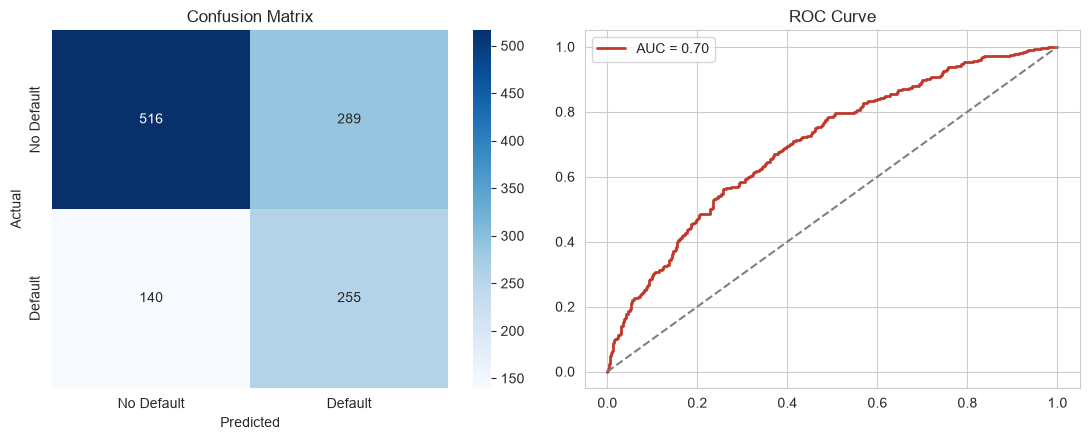

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Default","Default"], yticklabels=["No Default","Default"])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#c0392b", linewidth=2, label=f"AUC = {auc:.2f}")
axes[1].plot([0,1],[0,1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve"); axes[1].legend()

plt.tight_layout()
plt.show()


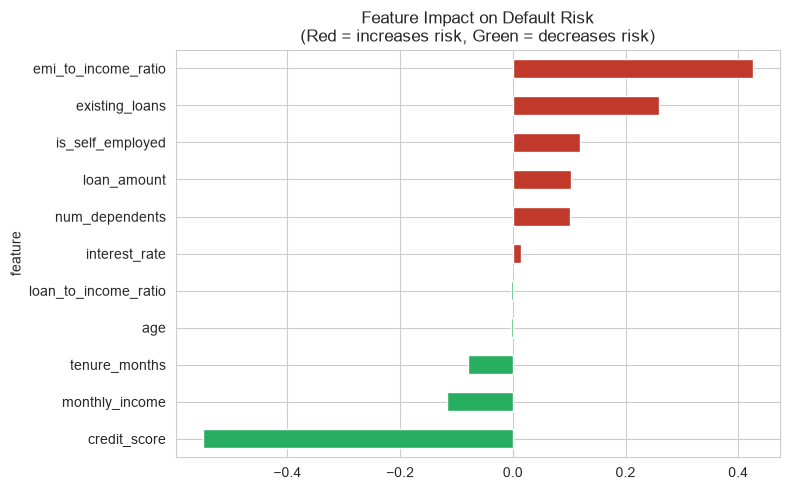

,feature,coefficient
2,credit_score,-0.549546
8,emi_to_income_ratio,0.425360
6,existing_loans,0.260032
10,is_self_employed,0.118673
1,monthly_income,-0.116798
3,loan_amount,0.103590
7,num_dependents,0.101308
5,tenure_months,-0.080250
4,interest_rate,0.013675
0,age,-0.004089


In [10]:
coef_df = pd.DataFrame({"feature": features, "coefficient": model.coef_[0]}) \
    .sort_values("coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
colors = ["#c0392b" if c > 0 else "#27ae60" for c in coef_df.sort_values("coefficient")["coefficient"]]
coef_df.sort_values("coefficient").plot(kind="barh", x="feature", y="coefficient",
                                          ax=ax, legend=False, color=colors)
ax.set_title("Feature Impact on Default Risk\n(Red = increases risk, Green = decreases risk)")
plt.tight_layout()
plt.show()

coef_df


## 7. Business Insights & Recommendations

1. **Credit score is the single strongest predictor** — applicants below 600 default at ~48%, nearly 3x the rate of 800+ applicants. Recommend tightening auto-approval thresholds below 620.
2. **EMI-to-income ratio above ~0.5 sharply raises risk** — recommend capping approved EMI at 40% of monthly income regardless of credit score.
3. **Self-employed applicants carry higher risk** despite higher average income — recommend requiring additional income verification (bank statements, ITR) for this segment.
4. **Medical and Vehicle loan purposes show above-average default rates** — consider shorter tenures or slightly higher risk-based pricing for these categories.
5. The baseline model (ROC-AUC ≈ 0.70) is usable as an **early-warning score to prioritize manual underwriting review**, not as a fully automated rejection engine — recall on defaulters (65%) still misses a meaningful share, so human review remains important for borderline cases.

## 8. Tools & Skills Demonstrated
`SQL (SQLite)` · `Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `Scikit-learn` · `EDA` · `Feature Engineering` · `Data Cleaning` · `Logistic Regression` · `Model Evaluation (ROC-AUC, Precision/Recall)`
